Dataset shape: (50000, 21)
Numerical columns: ['CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore']
Categorical columns: ['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'ExtraCurricular']

Missing values:
Gender                   0
City                     0
CollegeTier              0
Stream                   0
Specialisation           0
Hostel                   0
HistoryOfBacklogs        0
CGPA                     0
AttendancePercent        0
Internships              0
Projects                 0
Workshops             4488
Certifications           0
Publications             0
AptitudeTestScore     4029
SoftSkillsRating      3526
CodingTestScore       2976
MockInterviewScore    4957
ExtraCurricular          0
dtype: int64

Processed shape: (50000, 41)

Running Isolation Forest...

ISOLATION FOREST RESULTS
Total r

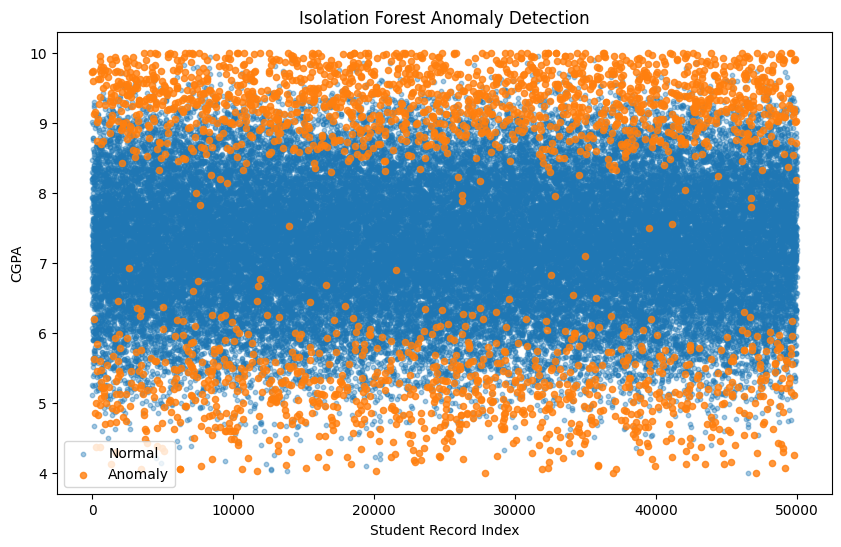

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest


# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv("/content/placement_predict_50k_adjusted (1).csv")

print("Dataset shape:", df.shape)


# ==========================================
# 2. REMOVE TARGET AND EXISTING ANOMALY
# ==========================================

X = df.drop(
    columns=["PlacementStatus", "IsAnomaly"],
    errors="ignore"
)


# ==========================================
# 3. IDENTIFY COLUMN TYPES
# ==========================================

categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)


# ==========================================
# 4. CHECK MISSING VALUES
# ==========================================

print("\nMissing values:")
print(X.isnull().sum())


# ==========================================
# 5. NUMERICAL PIPELINE
# ==========================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ==========================================
# 6. CATEGORICAL PIPELINE
# ==========================================

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)


# ==========================================
# 7. COMBINE PREPROCESSING
# ==========================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numerical_cols
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_cols
        )
    ]
)


# ==========================================
# 8. PREPROCESS DATA
# ==========================================

X_processed = preprocessor.fit_transform(X)

print("\nProcessed shape:", X_processed.shape)


# ==========================================
# 9. ISOLATION FOREST
# ==========================================

print("\nRunning Isolation Forest...")

model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

predictions = model.fit_predict(X_processed)


# ==========================================
# 10. ADD PREDICTIONS TO DATASET
# ==========================================

df["PredictedAnomaly"] = predictions

df["AnomalyLabel"] = df[
    "PredictedAnomaly"
].map(
    {
        1: "Normal",
        -1: "Anomaly"
    }
)


# ==========================================
# 11. COUNT NORMAL AND ANOMALOUS RECORDS
# ==========================================

normal_count = (
    df["PredictedAnomaly"] == 1
).sum()

anomaly_count = (
    df["PredictedAnomaly"] == -1
).sum()


print("\n================================")
print("ISOLATION FOREST RESULTS")
print("================================")

print("Total records:", len(df))
print("Normal records:", normal_count)
print("Anomalous records:", anomaly_count)


# ==========================================
# 12. DISPLAY FIRST 20 RESULTS
# ==========================================

print("\nFirst 20 results:")

print(
    df[
        [
            "PlacementStatus",
            "PredictedAnomaly",
            "AnomalyLabel"
        ]
    ].head(20)
)


# ==========================================
# 13. SAVE RESULTS
# ==========================================

df.to_csv(
    "placement_isolation_forest_results.csv",
    index=False
)

print(
    "\nResults saved to "
    "placement_isolation_forest_results.csv"
)


# ==========================================
# 14. VISUALIZATION
# ==========================================

# Use CGPA for a simple visualization

if "CGPA" in df.columns:

    plt.figure(figsize=(10, 6))

    normal = df[
        df["PredictedAnomaly"] == 1
    ]

    anomaly = df[
        df["PredictedAnomaly"] == -1
    ]

    plt.scatter(
        normal.index,
        normal["CGPA"],
        alpha=0.4,
        s=10,
        label="Normal"
    )

    plt.scatter(
        anomaly.index,
        anomaly["CGPA"],
        alpha=0.8,
        s=20,
        label="Anomaly"
    )

    plt.xlabel("Student Record Index")
    plt.ylabel("CGPA")

    plt.title(
        "Isolation Forest Anomaly Detection"
    )

    plt.legend()

    plt.show()